# PDSI Analysis: Weighted Average and Random State

This notebook analyzes Palmer Drought Severity Index (PDSI) data:
1. **Weighted Average PDSI** - Aggregated across all states using production weights
2. **Random State PDSI** - PDSI for a randomly selected state

Example uses **wheat** production data for weighting.

## Imports

In [1]:
import sys
import warnings
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR
from src.dataset.util.production_by_state import load_production_weights
from src.dataset.climate.pdsi import build_state_pdsi_frame

## Settings

In [2]:
# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
FIGSIZE = (16, 6)

# Crop to analyze
CROP = 'wheat'

# Paths
PALMER_DIR = DATA_DIR / 'climate' / 'palmer'
PRODUCTION_DIR = DATA_DIR / 'production_by_state'

# Random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Data

In [3]:
# Load state-level PDSI data
print("Loading state-level PDSI data...")
state_pdsi = build_state_pdsi_frame(PALMER_DIR)

print(f"\nState PDSI shape: {state_pdsi.shape}")
print(f"Date range: {state_pdsi['date'].min()} to {state_pdsi['date'].max()}")
print(f"Number of states: {state_pdsi['state'].nunique()}")
print(f"\nStates: {sorted(state_pdsi['state'].unique())}")
state_pdsi.head(10)

Loading state-level PDSI data...

State PDSI shape: (50880, 3)
Date range: 2004-12-27 00:00:00 to 2025-12-08 00:00:00
Number of states: 48

States: ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


,date,state,pdsi
0,2004-12-27,Alabama,2.432500
1,2004-12-27,Arizona,1.682857
2,2004-12-27,Arkansas,0.648889
3,2004-12-27,California,1.572857
4,2004-12-27,Colorado,0.412000
5,2004-12-27,Connecticut,0.626667
6,2004-12-27,Delaware,1.945000
7,2004-12-27,Florida,0.143333
8,2004-12-27,Georgia,2.514444
9,2004-12-27,Idaho,0.472000


In [5]:
# Load production weights for wheat
print(f"\nLoading production weights for {CROP}...")
production_weights = load_production_weights(CROP, PRODUCTION_DIR)

print(f"\nProduction weights shape: {production_weights.shape}")
print(f"\nTop 10 states by production weight:")
print(production_weights.sort_values('state_weight', ascending=False).head(10))


Loading production weights for wheat...

Production weights shape: (49, 2)

Top 10 states by production weight:
           state  state_weight
14        Kansas      0.149011
32  North Dakota      0.129402
34      Oklahoma      0.067442
24       Montana      0.063793
45    Washington      0.061253
25      Nebraska      0.042512
39  South Dakota      0.042490
21     Minnesota      0.041396
41         Texas      0.037786
10         Idaho      0.036192


## Calculate Weighted Average PDSI

In [6]:
# Merge PDSI with production weights
merged = state_pdsi.merge(production_weights, on='state', how='left')
merged['state_weight'] = merged['state_weight'].fillna(0.0)

# Calculate weighted PDSI
merged['weighted_pdsi'] = merged['pdsi'] * merged['state_weight']

# Aggregate by date
weighted_pdsi = merged.groupby('date', as_index=False)['weighted_pdsi'].sum()
weighted_pdsi.rename(columns={'weighted_pdsi': 'pdsi'}, inplace=True)

print(f"Weighted PDSI shape: {weighted_pdsi.shape}")
print(f"Date range: {weighted_pdsi['date'].min()} to {weighted_pdsi['date'].max()}")
print(f"\nWeighted PDSI statistics:")
print(weighted_pdsi['pdsi'].describe())
weighted_pdsi.head(10)

Weighted PDSI shape: (1060, 2)
Date range: 2004-12-27 00:00:00 to 2025-12-08 00:00:00

Weighted PDSI statistics:
count    1060.000000
mean        0.341711
std         1.174167
min        -2.579334
25%        -0.604219
50%         0.330491
75%         1.214620
max         3.240692
Name: pdsi, dtype: float64


,date,pdsi
0,2004-12-27,0.950999
1,2005-01-03,1.463210
2,2005-01-10,1.582210
3,2005-01-17,1.523141
4,2005-01-24,1.406288
5,2005-01-31,1.160060
6,2005-02-07,1.232892
7,2005-02-14,1.255138
8,2005-02-21,1.182886
9,2005-02-28,0.920399


## Select Random State

In [7]:
# Get states with production weights (i.e., states that produce wheat)
producing_states = production_weights[production_weights['state_weight'] > 0]['state'].tolist()

# Select a random state
random_state = random.choice(producing_states)

print(f"Randomly selected state: {random_state}")
print(f"Production weight: {production_weights[production_weights['state'] == random_state]['state_weight'].values[0]:.4f}")

# Filter PDSI for the random state
random_state_pdsi = state_pdsi[state_pdsi['state'] == random_state].copy()

print(f"\nRandom state PDSI shape: {random_state_pdsi.shape}")
print(f"Date range: {random_state_pdsi['date'].min()} to {random_state_pdsi['date'].max()}")
print(f"\nRandom state PDSI statistics:")
print(random_state_pdsi['pdsi'].describe())
random_state_pdsi.head(10)

Randomly selected state: Tennessee
Production weight: 0.0076

Random state PDSI shape: (1060, 3)
Date range: 2004-12-27 00:00:00 to 2025-12-08 00:00:00

Random state PDSI statistics:
count    1060.000000
mean        0.401881
std         1.932355
min        -4.580000
25%        -1.051250
50%         0.412500
75%         1.718125
max         5.030000
Name: pdsi, dtype: float64


,date,state,pdsi
39,2004-12-27,Tennessee,3.3300
87,2005-01-03,Tennessee,3.6125
135,2005-01-10,Tennessee,3.6500
183,2005-01-17,Tennessee,3.1525
231,2005-01-24,Tennessee,2.8125
279,2005-01-31,Tennessee,2.2550
327,2005-02-07,Tennessee,1.7825
375,2005-02-14,Tennessee,1.3925
423,2005-02-21,Tennessee,2.0425
471,2005-02-28,Tennessee,1.6250


## Plot 1: Weighted Average PDSI

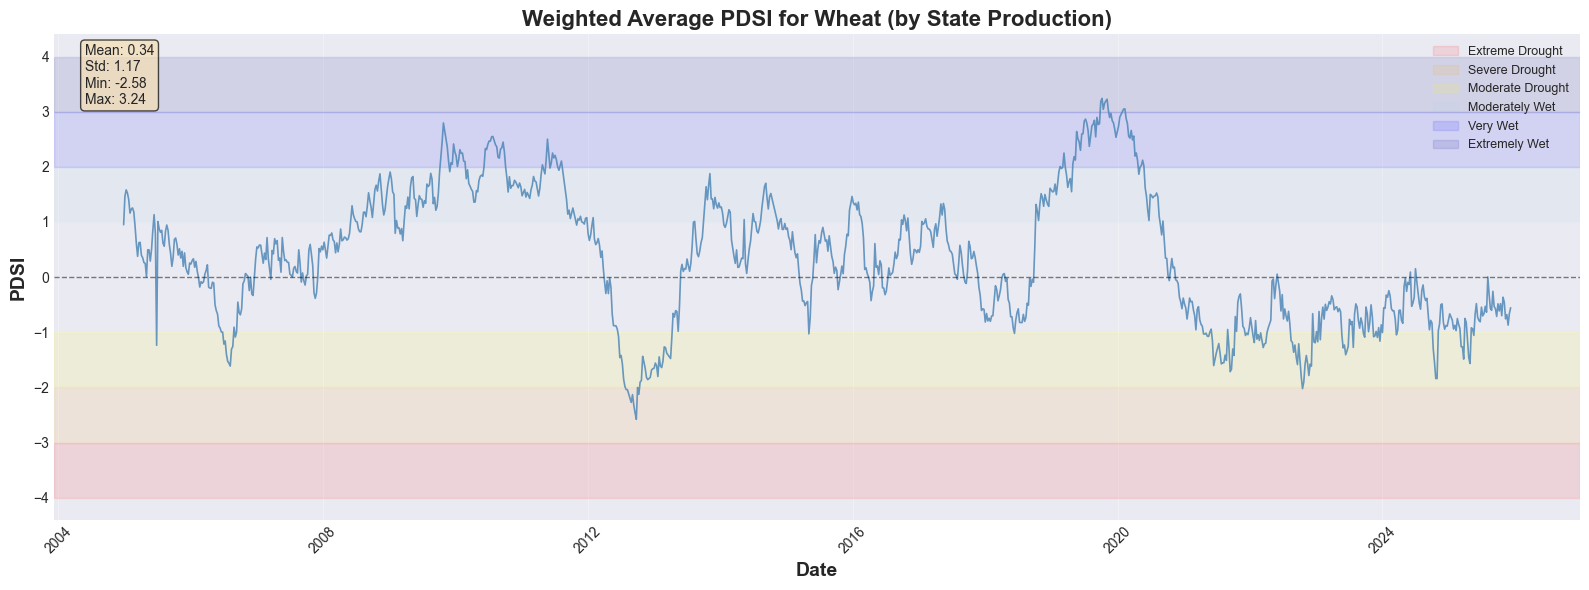

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE)

# Plot weighted PDSI
ax.plot(weighted_pdsi['date'], weighted_pdsi['pdsi'], color='steelblue', linewidth=1.2, alpha=0.8)

# Add horizontal line at zero
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add drought severity zones
ax.axhspan(-4, -3, alpha=0.1, color='red', label='Extreme Drought')
ax.axhspan(-3, -2, alpha=0.1, color='orange', label='Severe Drought')
ax.axhspan(-2, -1, alpha=0.1, color='yellow', label='Moderate Drought')
ax.axhspan(1, 2, alpha=0.1, color='lightblue', label='Moderately Wet')
ax.axhspan(2, 3, alpha=0.1, color='blue', label='Very Wet')
ax.axhspan(3, 4, alpha=0.1, color='darkblue', label='Extremely Wet')

ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('PDSI', fontsize=14, fontweight='bold')
ax.set_title(f'Weighted Average PDSI for {CROP.capitalize()} (by State Production)', 
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

# Add statistics box
stats_text = f"Mean: {weighted_pdsi['pdsi'].mean():.2f}\nStd: {weighted_pdsi['pdsi'].std():.2f}\nMin: {weighted_pdsi['pdsi'].min():.2f}\nMax: {weighted_pdsi['pdsi'].max():.2f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plot 2: Random State PDSI

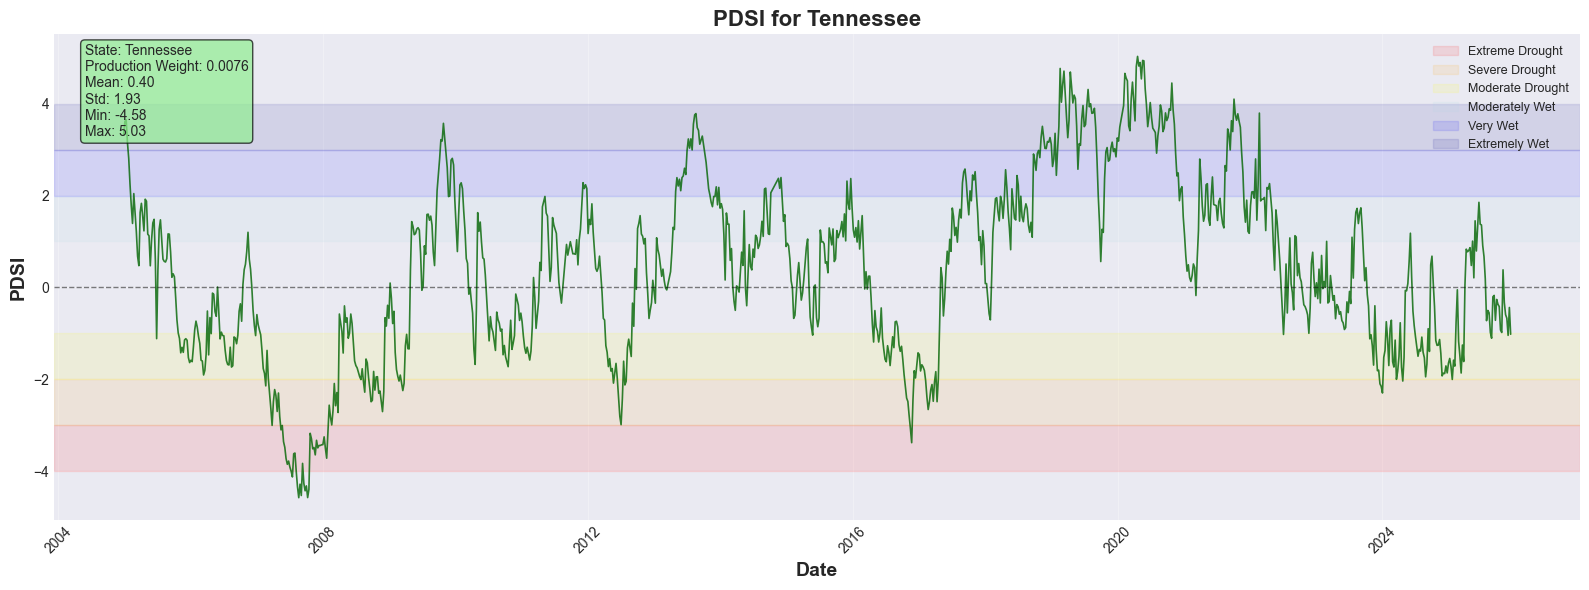

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)

# Plot random state PDSI
ax.plot(random_state_pdsi['date'], random_state_pdsi['pdsi'], color='darkgreen', linewidth=1.2, alpha=0.8)

# Add horizontal line at zero
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add drought severity zones
ax.axhspan(-4, -3, alpha=0.1, color='red', label='Extreme Drought')
ax.axhspan(-3, -2, alpha=0.1, color='orange', label='Severe Drought')
ax.axhspan(-2, -1, alpha=0.1, color='yellow', label='Moderate Drought')
ax.axhspan(1, 2, alpha=0.1, color='lightblue', label='Moderately Wet')
ax.axhspan(2, 3, alpha=0.1, color='blue', label='Very Wet')
ax.axhspan(3, 4, alpha=0.1, color='darkblue', label='Extremely Wet')

ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('PDSI', fontsize=14, fontweight='bold')
ax.set_title(f'PDSI for {random_state}', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

# Add statistics box
state_weight = production_weights[production_weights['state'] == random_state]['state_weight'].values[0]
stats_text = f"State: {random_state}\nProduction Weight: {state_weight:.4f}\nMean: {random_state_pdsi['pdsi'].mean():.2f}\nStd: {random_state_pdsi['pdsi'].std():.2f}\nMin: {random_state_pdsi['pdsi'].min():.2f}\nMax: {random_state_pdsi['pdsi'].max():.2f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bonus: Side-by-Side Comparison

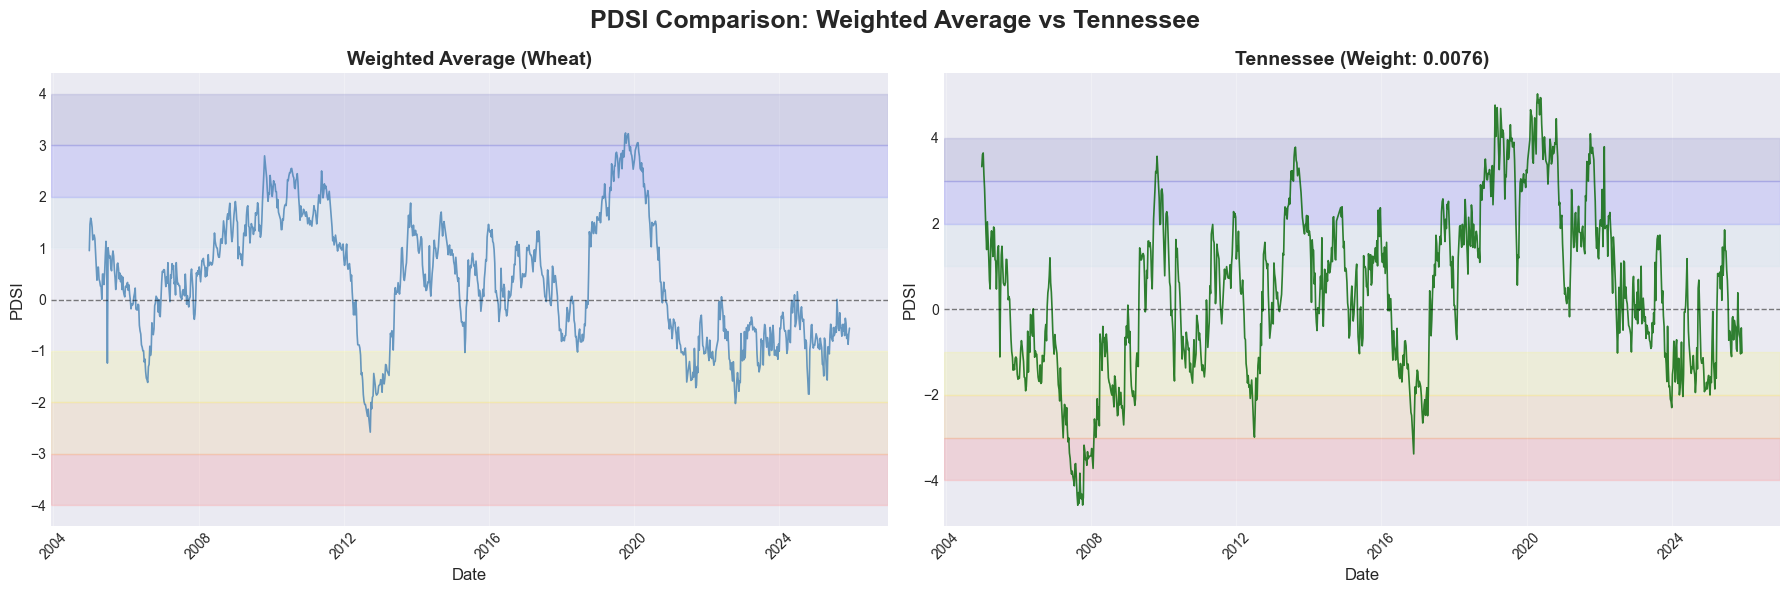

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'PDSI Comparison: Weighted Average vs {random_state}', fontsize=18, fontweight='bold')

# Plot 1: Weighted Average
axes[0].plot(weighted_pdsi['date'], weighted_pdsi['pdsi'], color='steelblue', linewidth=1.2, alpha=0.8)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axhspan(-4, -3, alpha=0.1, color='red')
axes[0].axhspan(-3, -2, alpha=0.1, color='orange')
axes[0].axhspan(-2, -1, alpha=0.1, color='yellow')
axes[0].axhspan(1, 2, alpha=0.1, color='lightblue')
axes[0].axhspan(2, 3, alpha=0.1, color='blue')
axes[0].axhspan(3, 4, alpha=0.1, color='darkblue')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('PDSI', fontsize=12)
axes[0].set_title(f'Weighted Average ({CROP.capitalize()})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Random State
axes[1].plot(random_state_pdsi['date'], random_state_pdsi['pdsi'], color='darkgreen', linewidth=1.2, alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axhspan(-4, -3, alpha=0.1, color='red')
axes[1].axhspan(-3, -2, alpha=0.1, color='orange')
axes[1].axhspan(-2, -1, alpha=0.1, color='yellow')
axes[1].axhspan(1, 2, alpha=0.1, color='lightblue')
axes[1].axhspan(2, 3, alpha=0.1, color='blue')
axes[1].axhspan(3, 4, alpha=0.1, color='darkblue')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('PDSI', fontsize=12)
axes[1].set_title(f'{random_state} (Weight: {state_weight:.4f})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()